# Person specfic analysis (i.e, scores)

In [147]:
import pandas as pd
from pandas import DataFrame

input_folder_base = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended-10pct"
input_folder_policy = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct-deparking-p2_d0_i0_max1000"

pct=0.1

def read_persons(input_folder):
    # person column is a string
    df = pd.read_csv(input_folder + "/berlin-v6.4.output_persons.csv.zst", sep=";", low_memory=False,
                     dtype={"person": "string"}, )
    df["monetarized_score"] = df["executed_score"] / df["marginalUtilityOfMoney"]
    return df


base_persons = read_persons(input_folder_base)
policy_persons = read_persons(input_folder_policy)
base_persons

,person,executed_score,first_act_x,first_act_y,first_act_type,RegioStaR7,age,ars,bikeAvail,carAvail,...,subpopulation,ref_id,ref_modes,ref_weight,lor,zone,purpose,tourStartArea,vehicleTypes,monetarized_score
0,bb_00005bd6,126.900350,789538.61,5813719.01,home_86400,3.0,49.0,1.206906e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143.732616
1,bb_00005f6f,97.470784,766625.23,5872598.05,home_86400,7.0,40.0,1.206858e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.892039
2,bb_000138d3,101.463528,760893.83,5820905.28,home_86400,4.0,32.0,1.206301e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.415079
3,bb_0001abb4,138.403875,816610.56,5801049.33,home_86400,3.0,63.0,1.206103e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.757628
4,bb_00022fe7,72.432083,788926.06,5848288.43,home_86400,3.0,25.0,1.206501e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.103506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526106,goodsTraffic_re_vkz.1953_2_0,51.212904,813457.95,5831238.21,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,2.0,re_vkz.1953,org.matsim.vehicles.PersonVehicleTypes@a3fe186,NaN
526107,goodsTraffic_re_vkz.1953_4_0,51.589191,813664.13,5830509.58,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,4.0,re_vkz.1953,org.matsim.vehicles.PersonVehicleTypes@1e181007,NaN
526108,goodsTraffic_re_vkz.1953_4_3,31.810186,813538.09,5831115.83,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,4.0,re_vkz.1953,org.matsim.vehicles.PersonVehicleTypes@2fa25287,NaN
526109,goodsTraffic_re_vkz.1953_5_0,-59.816423,813536.93,5830719.42,commercial_start,NaN,NaN,NaN,NaN,NaN,...,goodsTraffic,NaN,NaN,NaN,NaN,NaN,5.0,re_vkz.1953,org.matsim.vehicles.PersonVehicleTypes@4dfed15b,NaN


In [148]:
# join bass and policy persons based on "person" column. retain all columns.
joined = base_persons.merge(policy_persons, on="person", suffixes=("_base", "_policy"))
joined = joined[joined["subpopulation_base"] == "person"]
joined

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,subpopulation_policy,ref_id_policy,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy
0,bb_00005bd6,126.900350,789538.610000,5.813719e+06,home_86400,3.0,49.0,1.206906e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143.401485
1,bb_00005f6f,97.470784,766625.230000,5.872598e+06,home_86400,7.0,40.0,1.206858e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.705305
2,bb_000138d3,101.463528,760893.830000,5.820905e+06,home_86400,4.0,32.0,1.206301e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.415079
3,bb_0001abb4,138.403875,816610.560000,5.801049e+06,home_86400,3.0,63.0,1.206103e+11,never,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.757628
4,bb_00022fe7,72.432083,788926.060000,5.848288e+06,home_86400,3.0,25.0,1.206501e+11,always,always,...,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.103506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492869,berlin_fffe9f24,0.000000,784286.269230,5.826645e+06,home_86400,1.0,70.0,1.100000e+11,always,always,...,person,NaN,NaN,NaN,5020628.0,5.0,NaN,NaN,NaN,0.000000
492870,berlin_fffebae6,152.958369,797856.841328,5.830950e+06,home_86400,1.0,69.0,1.100000e+11,always,always,...,person,NaN,NaN,NaN,1033201.0,1.0,NaN,NaN,NaN,181.029220
492871,berlin_ffff51e3,156.725237,809682.203822,5.831328e+06,home_86400,1.0,63.0,1.100000e+11,never,always,...,person,NaN,NaN,NaN,10010310.0,10.0,NaN,NaN,NaN,177.472223
492872,berlin_ffff7d17,164.006914,793480.829153,5.821738e+06,home_86400,1.0,25.0,1.100000e+11,never,always,...,person,NaN,NaN,NaN,6010103.0,6.0,NaN,NaN,NaN,239.209576


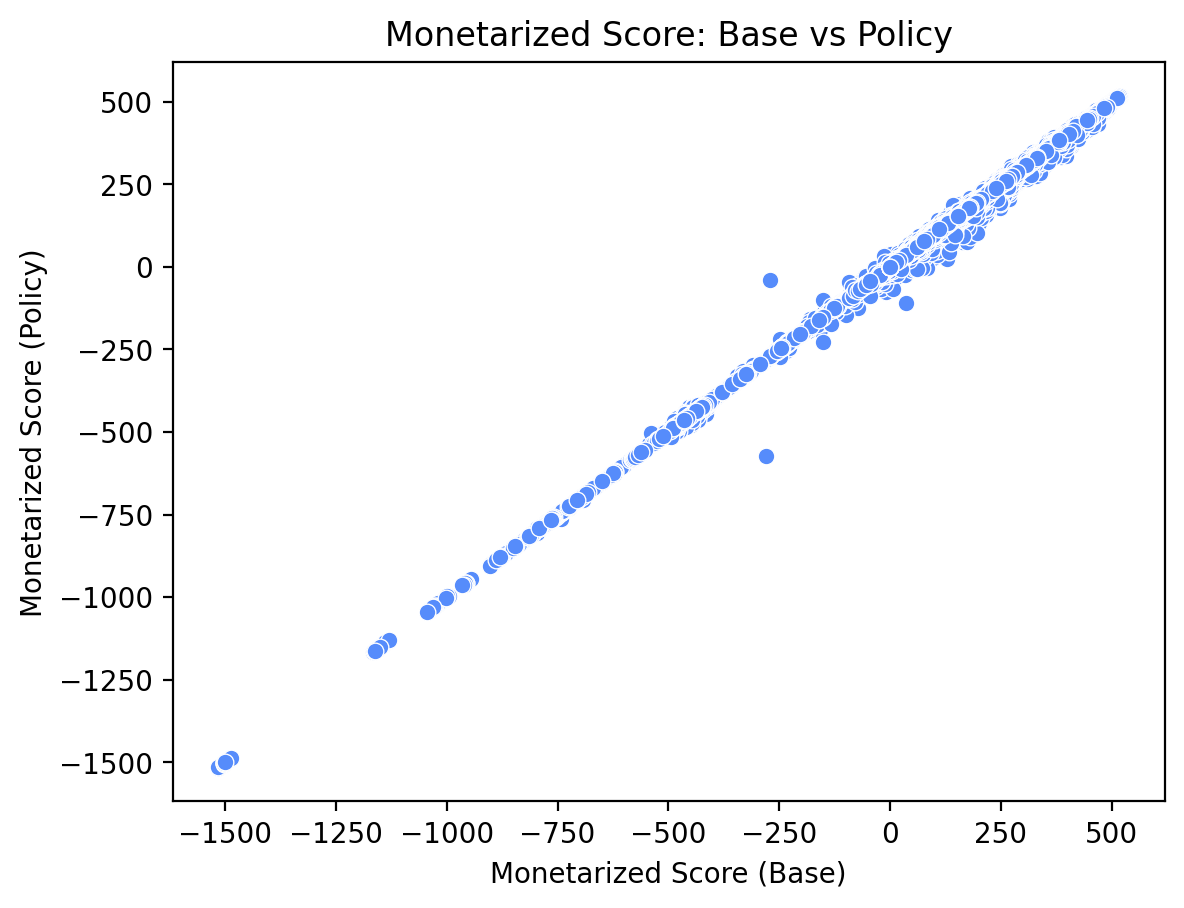

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'


sns.scatterplot(data=joined, x="monetarized_score_base", y="monetarized_score_policy")
plt.xlabel("Monetarized Score (Base)")
plt.ylabel("Monetarized Score (Policy)")
plt.title("Monetarized Score: Base vs Policy")
plt.show()

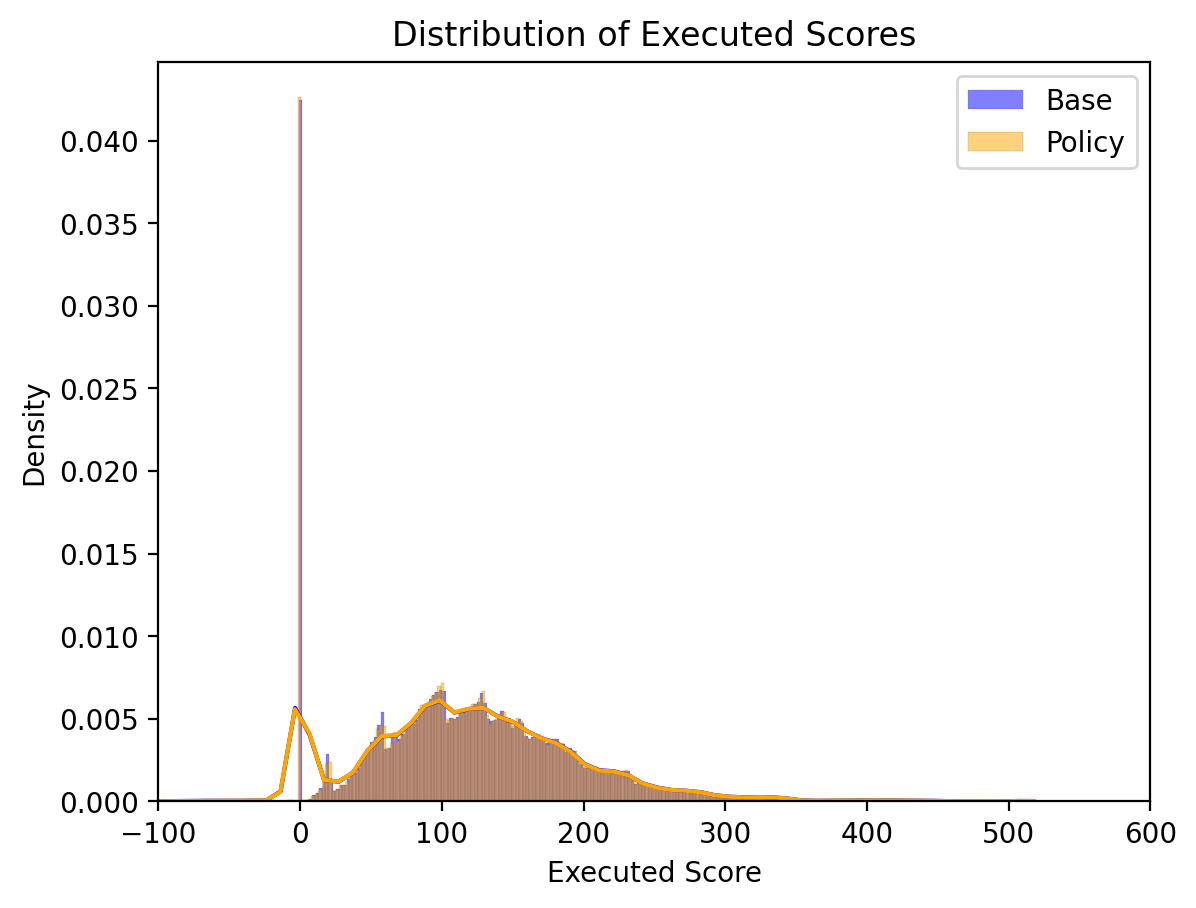

In [150]:
# plot the distribution of executed_score_base and executed_score_policy as histograms
sns.histplot(joined["monetarized_score_base"], color="blue", label="Base", kde=True, stat="density")
sns.histplot(joined["monetarized_score_policy"], color="orange", label="Policy", kde=True, stat="density")

# restrict x axis to -100 to 200
plt.xlim(-100, 600)
plt.xlabel("Executed Score")
plt.ylabel("Density")
plt.title("Distribution of Executed Scores")
plt.legend()
plt.show()

In [151]:
# plot the diff between monetarized_score_base and monetarized_score_policy as a histogram
joined["monetarized_score_diff"] = joined["monetarized_score_policy"] - joined["monetarized_score_base"]
print(joined["monetarized_score_diff"].describe())


count    492874.000000
mean         -0.293516
std           2.501529
min        -292.469193
25%          -0.005272
50%           0.000000
75%           0.000000
max         231.622647
Name: monetarized_score_diff, dtype: float64


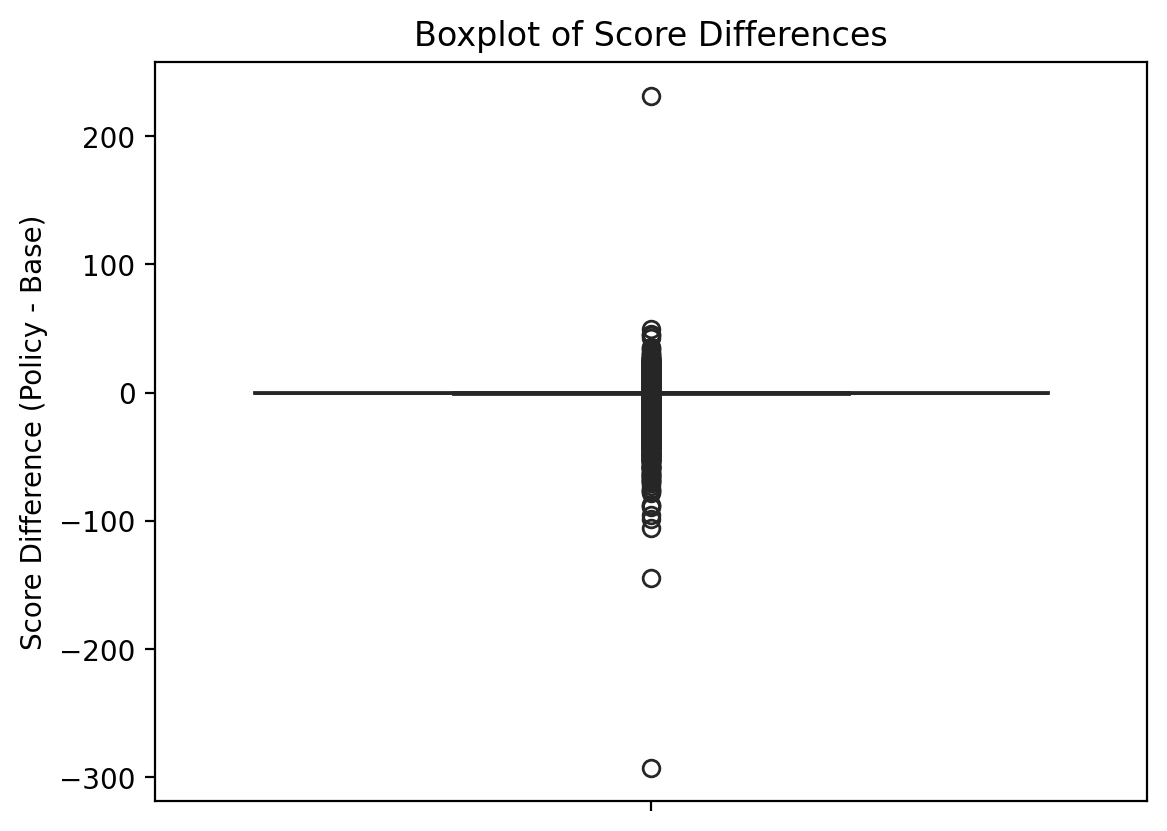

In [152]:
changed_persons = joined.loc[joined["monetarized_score_diff"] != 0.0].copy()

sns.boxplot(data=changed_persons, y="monetarized_score_diff", color="green")
plt.ylabel("Score Difference (Policy - Base)")
plt.title("Boxplot of Score Differences")
plt.show()


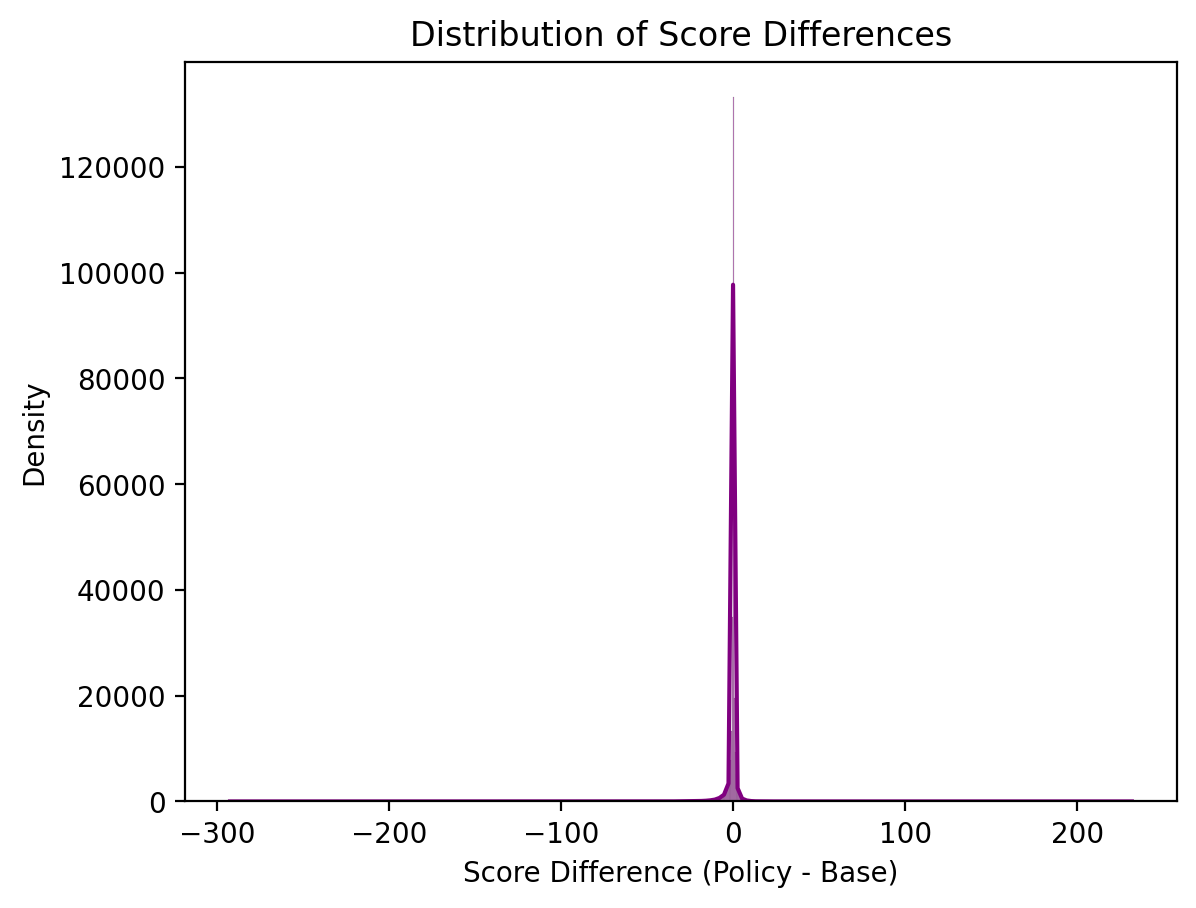

In [153]:
# create a distribution of the score differences
sns.histplot(changed_persons["monetarized_score_diff"], color="purple", kde=True)
plt.xlabel("Score Difference (Policy - Base)")
plt.ylabel("Density")
plt.title("Distribution of Score Differences")
plt.show()

In [154]:
changed_persons["score_diff"] = changed_persons["executed_score_policy"] - changed_persons["executed_score_base"]
changed_persons

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy,monetarized_score_diff,score_diff
0,bb_00005bd6,126.900350,789538.610000,5.813719e+06,home_86400,3.0,49.0,1.206906e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143.401485,-0.331131,-0.292353
1,bb_00005f6f,97.470784,766625.230000,5.872598e+06,home_86400,7.0,40.0,1.206858e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.705305,-0.186735,-0.272098
5,bb_000381a6,147.552460,813244.570000,5.810635e+06,home_86400,3.0,2.0,1.206104e+11,always,never,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.286124,0.001508,0.001500
6,bb_0003c43f,151.694622,823716.110000,5.830710e+06,home_86400,3.0,58.0,1.206404e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,214.024411,0.582527,0.414006
8,bb_00052a5a,153.323318,778003.040000,5.812949e+06,home_86400,2.0,26.0,1.205400e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.885137,0.161300,0.261086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492866,berlin_fffe31fe,152.743736,803157.676934,5.826948e+06,home_86400,1.0,9.0,1.100000e+11,always,never,...,NaN,NaN,2050801.0,2.0,NaN,NaN,NaN,154.237354,-0.050679,-0.050172
492867,berlin_fffe88e3,104.798081,783633.885427,5.826242e+06,home_86400,1.0,16.0,1.100000e+11,always,never,...,NaN,NaN,5020524.0,5.0,NaN,NaN,NaN,113.551096,3.485060,3.318259
492868,berlin_fffe8de9,-56.028818,799276.428714,5.826790e+06,home_30000,1.0,34.0,1.100000e+11,always,always,...,NaN,NaN,1011305.0,1.0,NaN,NaN,NaN,-43.729746,1.586871,1.961985
492870,berlin_fffebae6,152.958369,797856.841328,5.830950e+06,home_86400,1.0,69.0,1.100000e+11,always,always,...,NaN,NaN,1033201.0,1.0,NaN,NaN,NaN,181.029220,-0.092657,-0.078249


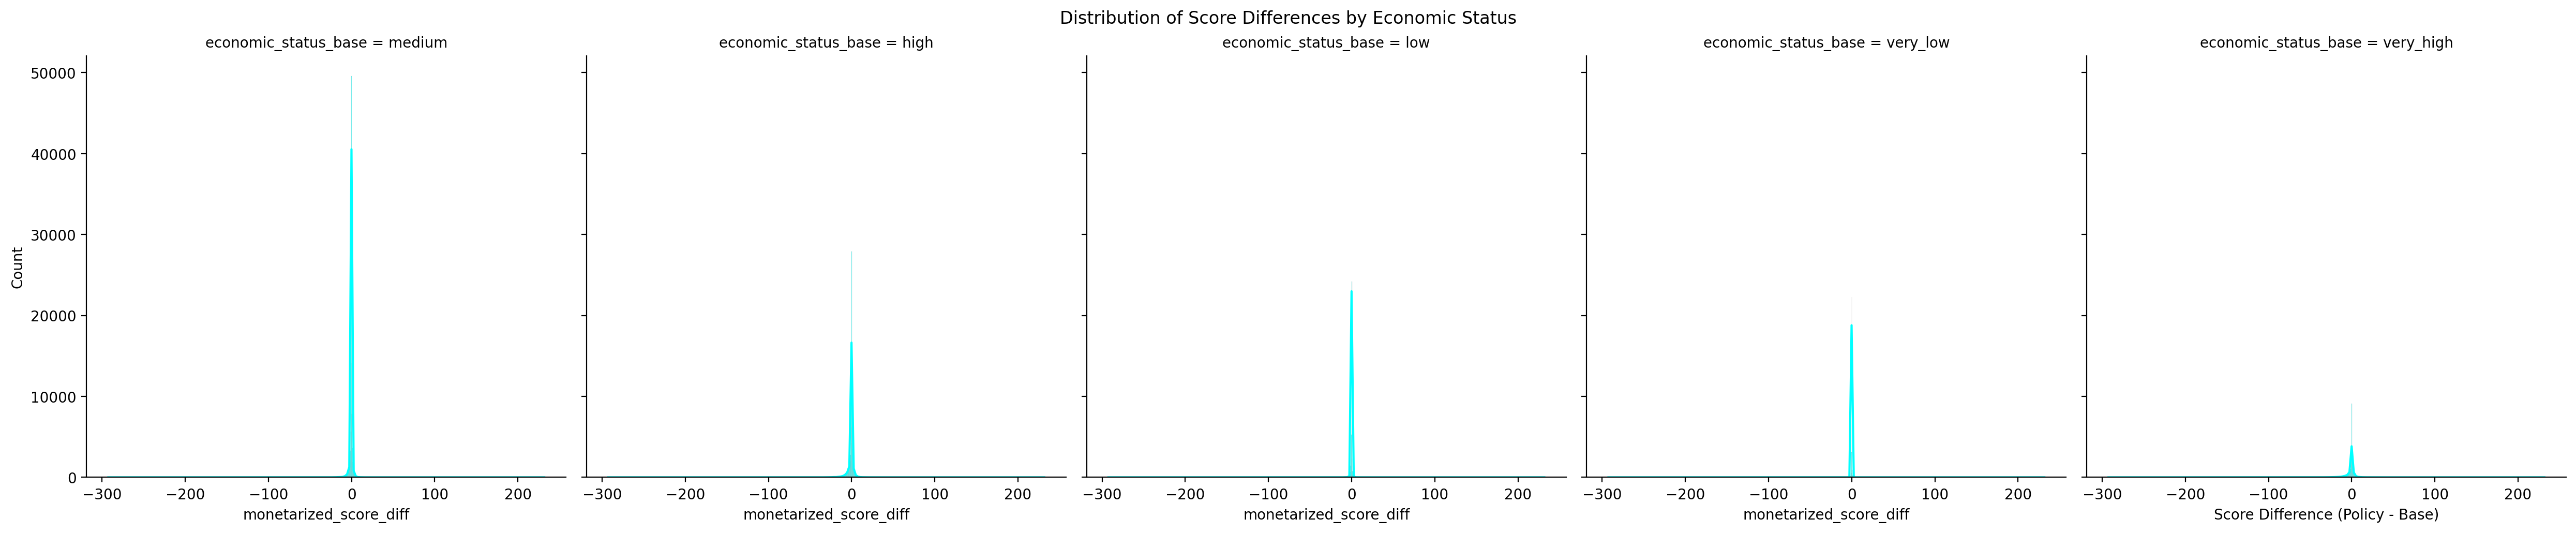

In [155]:
# do a facet plot: for each economic_status plot the distribution of score differences
sns.displot(data=changed_persons, x="monetarized_score_diff", col="economic_status_base", color="cyan", kde=True)
plt.xlabel("Score Difference (Policy - Base)")
plt.ylabel("Density")
plt.suptitle("Distribution of Score Differences by Economic Status", y=1.02)
plt.show()

In [156]:
# for each economic_status describe the score differences
for status in changed_persons["economic_status_base"].unique():
    subset = changed_persons[changed_persons["economic_status_base"] == status]
    print(f"Economic Status: {status}")
    print(subset["monetarized_score_diff"].describe())
    print("\n")


Economic Status: medium
count    99845.000000
mean        -0.340104
std          2.263100
min        -77.111587
25%         -0.342279
50%         -0.000107
75%          0.152071
max         49.529147
Name: monetarized_score_diff, dtype: float64


Economic Status: high
count    75176.000000
mean        -0.815583
std          4.053537
min       -144.188682
25%         -0.841079
50%         -0.006095
75%          0.302335
max         45.416121
Name: monetarized_score_diff, dtype: float64


Economic Status: low
count    3.650300e+04
mean    -9.278927e-02
std      1.039784e+00
min     -3.093850e+01
25%     -1.051411e-01
50%     -2.842171e-14
75%      6.182706e-02
max      2.999812e+01
Name: monetarized_score_diff, dtype: float64


Economic Status: very_low
count    2.762400e+04
mean    -2.180794e-02
std      6.908059e-01
min     -3.039318e+01
25%     -3.471678e-02
50%     -7.105427e-15
75%      2.718932e-02
max      4.515259e+01
Name: monetarized_score_diff, dtype: float64


Economic Status

In [157]:
joined.sort_values(by=["monetarized_score_diff"], ascending=False).head(5)

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,ref_id_policy,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy,monetarized_score_diff
85381,bb_bbc04e3e,-172.047344,772637.470000,5.815851e+06,home_86400,2.0,34.0,1.205400e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-38.535234,231.622647
65490,bb_9022f49e,-189.054662,698149.960000,5.894607e+06,home_86400,7.0,36.0,1.207001e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-101.919994,49.529147
77767,bb_ab0dea67,-43.809464,829916.310000,5.715536e+06,home_27600,6.0,64.0,1.206602e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-47.058301,45.416121
230598,berlin_4dc3bae3,-37.654934,798420.928975,5.829156e+06,home_86400,1.0,22.0,1.100000e+11,always,always,...,NaN,NaN,NaN,1011401.0,1.0,NaN,NaN,NaN,31.582281,45.152591
441496,berlin_dd2a7d49,68.257059,795506.690374,5.831108e+06,home_86400,1.0,56.0,1.100000e+11,always,always,...,NaN,NaN,NaN,1044203.0,1.0,NaN,NaN,NaN,187.675697,44.756168


In [158]:
joined.sort_values(by=["monetarized_score_diff"], ascending=True).head(5)

,person,executed_score_base,first_act_x_base,first_act_y_base,first_act_type_base,RegioStaR7_base,age_base,ars_base,bikeAvail_base,carAvail_base,...,ref_id_policy,ref_modes_policy,ref_weight_policy,lor_policy,zone_policy,purpose_policy,tourStartArea_policy,vehicleTypes_policy,monetarized_score_policy,monetarized_score_diff
57019,bb_7dbd1efb,-178.638355,778871.340000,5.840646e+06,home_86400,4.0,34.0,1.206503e+11,always,always,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-572.976629,-292.469193
491785,berlin_ff4cd7f0,17.063342,800918.312786,5.824542e+06,home_86400,1.0,53.0,1.100000e+11,always,always,...,NaN,NaN,NaN,8010301.0,8.0,NaN,NaN,NaN,-108.170833,-144.188682
117437,berlin_00d01f94,86.135029,801491.338736,5.822809e+06,home_86400,1.0,47.0,1.100000e+11,always,always,...,NaN,NaN,NaN,8010213.0,8.0,NaN,NaN,NaN,22.943316,-105.880384
379185,berlin_b2a8d6cc,81.844082,799916.341801,5.824973e+06,home_86400,1.0,45.0,1.100000e+11,always,always,...,NaN,NaN,NaN,2020206.0,2.0,NaN,NaN,NaN,74.388097,-98.371017
453617,berlin_e5522d35,75.030581,801228.974170,5.824299e+06,home_86400,1.0,52.0,1.100000e+11,never,always,...,NaN,NaN,NaN,8010301.0,8.0,NaN,NaN,NaN,101.836084,-95.169400


# Sinple Score Deltas

In [159]:
import geopandas as gpd

bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson").to_crs(epsg=3857)
umweltzone = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/umweltzone/Umweltzone_Berlin.shp").to_crs(epsg=3857)
bezirke_outline = bezirke.union_all()

In [160]:
# join "joined" with bezirke and umweltzone. based on "home_x_base" and "home_y_base" cols, create a new column location: if in umweltzone then "IR", if in bezirke then in "OR", else "BRA". 
def cluster_persons_by_home(df, umweltzone, bezirke):
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(joined["home_x_base"], joined["home_y_base"]), crs="EPSG:25832")

    gdf["cluster"] = "BRA"
    gdf.loc[gdf.geometry.within(bezirke.to_crs("EPSG:25832").union_all()), "cluster"] = "OR"
    gdf.loc[gdf.geometry.within(umweltzone.to_crs("EPSG:25832").union_all()), "cluster"] = "IR"

    order = ["BRA", "OR", "IR"]
    gdf["cluster"] = pd.Categorical(
        gdf["cluster"],
        categories=order,
        ordered=True
    )

    return gdf

In [161]:
persons_clustered = cluster_persons_by_home(joined, umweltzone, bezirke)
persons_clustered["executed_score_diff"] = persons_clustered["executed_score_policy"] - persons_clustered["executed_score_base"]

In [162]:
persons_clustered["cluster"].value_counts()

cluster
OR     264640
BRA    115679
IR     112555
Name: count, dtype: int64

In [167]:
import pandas as pd
import numpy as np

def add_income_clusters(df: DataFrame) -> DataFrame:
    income_order = [
        "<1k",
        "1-2k",
        "2-3k",
        "3-4k",
        "4-5k",
        "5-6k",
        ">6k"
    ]

    df["income_cluster"] = pd.cut(
        df["income_base"],
        bins=[-np.inf, 1000, 2000, 3000, 4000, 5000, 6000, np.inf],
        labels=income_order,
        right=False  # [1000,2000), [2000,3000), ...
    )

    df["income_cluster"] = pd.Categorical(
        df["income_cluster"],
        categories=income_order,
        ordered=True
    )

    return df

In [168]:
persons_clustered = add_income_clusters(persons_clustered)

In [179]:
import pandas as pd

def print_cluster_score_differences(df: pd.DataFrame):
    def fmt_mean(x):
        return "" if x == "" else f"{x:,.2f}"

    def fmt_sum(x):
        return "" if x == "" else f"{x:,.0f}"

    cluster_summary = (
        df.groupby(["cluster", "income_cluster"])
        .agg(
            count=("person", "count"),
            executed_score_diff_mean=("executed_score_diff", "mean"),
            executed_score_diff_sum=("executed_score_diff", "sum"),
            monetarized_score_diff_mean=("monetarized_score_diff", "mean"),
            monetarized_score_diff_sum=("monetarized_score_diff", "sum"),
        )
        .reset_index()
    )

    cluster_summary["count"] /= pct
    cluster_summary["executed_score_diff_sum"] /= pct
    cluster_summary["monetarized_score_diff_sum"] /= pct

    cluster_summary = cluster_summary[cluster_summary["cluster"] != "BRA"]

    cluster_summary = cluster_summary.sort_values(
        ["cluster", "income_cluster"]
    )

    total_row = pd.DataFrame([{
        "cluster": "Total",
        "income_cluster": "",
        "count": cluster_summary["count"].sum(),
        "executed_score_diff_mean": "",
        "executed_score_diff_sum": cluster_summary["executed_score_diff_sum"].sum(),
        "monetarized_score_diff_mean": "",
        "monetarized_score_diff_sum": cluster_summary["monetarized_score_diff_sum"].sum(),
    }])

    cluster_summary = pd.concat([cluster_summary, total_row], ignore_index=True)

    cluster_summary["income_cluster"] = (
        cluster_summary["income_cluster"]
        .astype(str)
        .replace({
            "<1k": "$<1$k",
            ">6k": "$>6$k",
        })
    )

    cluster_summary["count"] = cluster_summary["count"].map(fmt_sum)
    cluster_summary["executed_score_diff_sum"] = cluster_summary["executed_score_diff_sum"].map(fmt_sum)
    cluster_summary["monetarized_score_diff_sum"] = cluster_summary["monetarized_score_diff_sum"].map(fmt_sum)

    cluster_summary["executed_score_diff_mean"] = cluster_summary["executed_score_diff_mean"].map(fmt_mean)
    cluster_summary["monetarized_score_diff_mean"] = cluster_summary["monetarized_score_diff_mean"].map(fmt_mean)

    cluster_summary.columns = pd.MultiIndex.from_tuples([
        ("", "Home"),
        ("", "Income [€]"),
        ("", r"Count"),
        ("Score [utils]", r"$\overline{\Delta}$"),
        ("Score [utils]", r"$\Sigma \Delta$"),
        ("Monetarized score [€]", r"$\overline{\Delta}$"),
        ("Monetarized score [€]", r"$\Sigma \Delta$"),
    ])

    # print(cluster_summary)

    latex = cluster_summary.to_latex(
        index=False,
        escape=False,
        column_format="lllllll",
        multicolumn=True,
        multicolumn_format="l",
    )

    latex = latex.replace(
        "Total &",
        r"\midrule" + "\n" + "Total &",
        1,
    )

    print(latex)

In [180]:
print_cluster_score_differences(persons_clustered)

\begin{tabular}{lllllll}
\toprule
\multicolumn{3}{l}{} & \multicolumn{2}{l}{Score [utils]} & \multicolumn{2}{l}{Monetarized score [€]} \\
Home & Income [€] & Count & $\overline{\Delta}$ & $\Sigma \Delta$ & $\overline{\Delta}$ & $\Sigma \Delta$ \\
\midrule
OR & $<1$k & 333,220 & -0.01 & -1,953 & -0.00 & -903 \\
OR & 1-2k & 1,175,380 & -0.07 & -77,138 & -0.06 & -65,267 \\
OR & 2-3k & 817,540 & -0.19 & -152,229 & -0.24 & -195,916 \\
OR & 3-4k & 186,640 & -0.26 & -48,781 & -0.45 & -83,663 \\
OR & 4-5k & 98,530 & -0.32 & -31,599 & -0.67 & -66,327 \\
OR & 5-6k & 14,580 & -0.23 & -3,296 & -0.59 & -8,653 \\
OR & $>6$k & 20,510 & -0.52 & -10,606 & -1.62 & -33,309 \\
IR & $<1$k & 146,510 & -0.04 & -6,295 & -0.02 & -2,605 \\
IR & 1-2k & 482,860 & -0.29 & -138,604 & -0.24 & -114,498 \\
IR & 2-3k & 352,190 & -0.78 & -275,800 & -1.00 & -353,618 \\
IR & 3-4k & 84,680 & -1.23 & -104,485 & -2.10 & -178,234 \\
IR & 4-5k & 44,720 & -1.73 & -77,435 & -3.64 & -162,638 \\
IR & 5-6k & 5,720 & -2.10 & -12,003